In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
import warnings

warnings.filterwarnings("ignore")

print("=" * 55)
print("  Library versions loaded successfully")
print("=" * 55)
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  matplotlib  : {plt.matplotlib.__version__}")
print(f"  seaborn     : {sns.__version__}")
print("=" * 55)


  Library versions loaded successfully
  pandas      : 3.0.2
  numpy       : 2.4.4
  matplotlib  : 3.10.8
  seaborn     : 0.13.2


In [15]:
DATA_PATH = "C:/Users/white/Downloads/Learn/Churn_project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Verify file exists before loading
if not os.path.exists(DATA_PATH):
    print("  FILE NOT FOUND.")
    print(f"  Expected at: {DATA_PATH}")
    print("  Please download from Kaggle and place in the /data folder.")
else:
    print(f"  Dataset found at: {DATA_PATH}")
    

  Dataset found at: C:/Users/white/Downloads/Learn/Churn_project/data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [16]:
df = pd.read_csv(DATA_PATH)

print("\n" + "=" * 55)
print("  BASIC SHAPE")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

# ── 3a. Column names overview ────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  ALL COLUMNS")
print("=" * 55)
for col in df.columns:
    print(f"  {col}")

# ── 3b. Data types ───────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DATA TYPES")
print("=" * 55)
print(df.dtypes.to_string())

# ── 3c. First 5 rows ─────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  FIRST 5 ROWS")
print("=" * 55)
print(df.head().to_string())

# ── 3d. Missing values ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count" : missing,
    "Missing %"     : missing_pct
})
print(missing_df[missing_df["Missing Count"] > 0].to_string())
print("\n  Note: TotalCharges may have blank strings — check below.")

# ── 3e. TotalCharges special check (known issue in this dataset) ─────────────
print("\n" + "=" * 55)
print("  TOTALCHARGES — BLANK STRING CHECK")
print("=" * 55)
tc_blanks = df[df["TotalCharges"].str.strip() == ""].shape[0]
print(f"  Rows where TotalCharges is blank : {tc_blanks}")
print("  These will be fixed in Day 4 (preprocessing).")
print("  For now, just note them.")

# ── 3f. Basic statistics ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  NUMERICAL COLUMN STATISTICS")
print("=" * 55)
print(df.describe().to_string())

# ── 3g. Churn distribution ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  TARGET COLUMN: CHURN DISTRIBUTION")
print("=" * 55)
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True).mul(100).round(2)
churn_summary = pd.DataFrame({
    "Count"   : churn_counts,
    "Percent %" : churn_pct
})
print(churn_summary.to_string())
print(f"\n  -> Class imbalance ratio: {churn_pct['No']:.1f}% retained vs {churn_pct['Yes']:.1f}% churned")
print("     This imbalance must be handled in the ML phase (Day 8).")


  BASIC SHAPE
  Rows    : 7,043
  Columns : 21

  ALL COLUMNS
  customerID
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  InternetService
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaperlessBilling
  PaymentMethod
  MonthlyCharges
  TotalCharges
  Churn

  DATA TYPES
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

  FIRST 5 ROWS
   customerID  ge


  COLUMN MEANINGS REFERENCE
  customerID           : Unique customer identifier — drop before ML
  gender               : Male / Female
  SeniorCitizen        : 1 = Senior (65+), 0 = Not senior
  Partner              : Has a partner? Yes / No
  Dependents           : Has dependents? Yes / No
  tenure               : Months with company — KEY churn predictor
  PhoneService         : Has phone service? Yes / No
  MultipleLines        : Multiple phone lines?
  InternetService      : DSL / Fiber optic / No — HIGH churn impact
  OnlineSecurity       : Has online security add-on?
  OnlineBackup         : Has online backup add-on?
  DeviceProtection     : Has device protection add-on?
  TechSupport          : Has tech support add-on?
  StreamingTV          : Streams TV?
  StreamingMovies      : Streams movies?
  Contract             : Month-to-month / 1yr / 2yr — STRONGEST predictor
  PaperlessBilling     : Uses paperless billing?
  PaymentMethod        : Electronic check / Mailed check / Ba

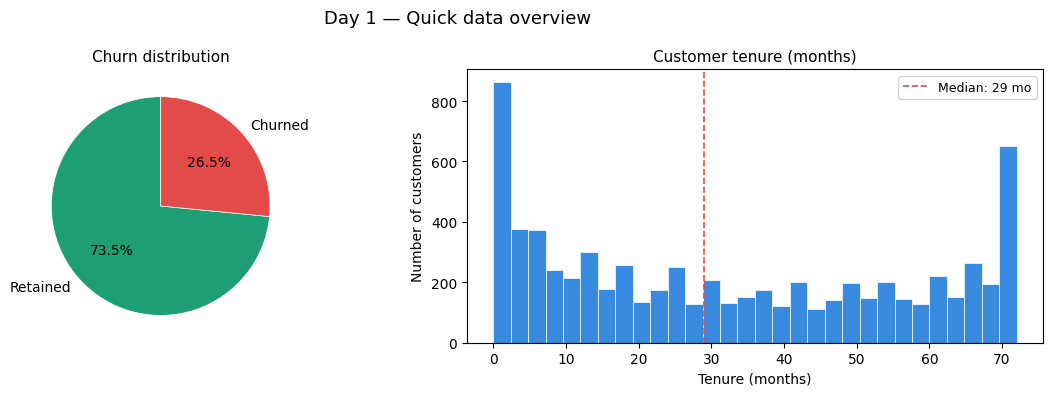


  Chart saved to /visuals/day1_overview.png


In [17]:
print("\n" + "=" * 55)
print("  COLUMN MEANINGS REFERENCE")
print("=" * 55)

column_guide = {
    "customerID"       : "Unique customer identifier — drop before ML",
    "gender"           : "Male / Female",
    "SeniorCitizen"    : "1 = Senior (65+), 0 = Not senior",
    "Partner"          : "Has a partner? Yes / No",
    "Dependents"       : "Has dependents? Yes / No",
    "tenure"           : "Months with company — KEY churn predictor",
    "PhoneService"     : "Has phone service? Yes / No",
    "MultipleLines"    : "Multiple phone lines?",
    "InternetService"  : "DSL / Fiber optic / No — HIGH churn impact",
    "OnlineSecurity"   : "Has online security add-on?",
    "OnlineBackup"     : "Has online backup add-on?",
    "DeviceProtection" : "Has device protection add-on?",
    "TechSupport"      : "Has tech support add-on?",
    "StreamingTV"      : "Streams TV?",
    "StreamingMovies"  : "Streams movies?",
    "Contract"         : "Month-to-month / 1yr / 2yr — STRONGEST predictor",
    "PaperlessBilling" : "Uses paperless billing?",
    "PaymentMethod"    : "Electronic check / Mailed check / Bank transfer / Credit card",
    "MonthlyCharges"   : "Monthly bill amount — KEY churn predictor",
    "TotalCharges"     : "Total billed to date (string! — needs conversion)",
    "Churn"            : "TARGET: Yes = churned, No = stayed"
}

for col, meaning in column_guide.items():
    print(f"  {col:<20} : {meaning}")


# ── QUICK VISUALISATION — Churn distribution chart ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Day 1 — Quick data overview", fontsize=13, fontweight="normal")

# Churn pie chart
churn_counts.plot(
    kind="pie",
    ax=axes[0],
    autopct="%1.1f%%",
    colors=["#1D9E75", "#E24B4A"],
    startangle=90,
    labels=["Retained", "Churned"],
    wedgeprops=dict(linewidth=0.5, edgecolor="white")
)
axes[0].set_title("Churn distribution", fontsize=11)
axes[0].set_ylabel("")

# Tenure distribution
axes[1].hist(
    df["tenure"],
    bins=30,
    color="#378ADD",
    edgecolor="white",
    linewidth=0.5
)
axes[1].set_title("Customer tenure (months)", fontsize=11)
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Number of customers")
axes[1].axvline(df["tenure"].median(), color="#E24B4A", linestyle="--",
                linewidth=1.2, label=f"Median: {df['tenure'].median():.0f} mo")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("C:/Users/white/Downloads/Learn/Churn_project/visuals/day1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved to /visuals/day1_overview.png")

In [18]:
print("\n" + "=" * 55)
print("  DAY 1 COMPLETE — KEY FINDINGS")
print("=" * 55)
print(f"  Dataset     : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Churn rate  : ~{churn_pct['Yes']:.1f}% (class imbalance — handle in Day 8)")
print(f"  Null values : Only TotalCharges has blanks ({tc_blanks} rows)")
print(f"  Key columns : tenure, Contract, MonthlyCharges, InternetService")
print("")
print("  TOMORROW — Day 2:")
print("  -> Create SQLite database from this dataframe")
print("  -> Write SQL queries for churn rate, revenue, segment breakdowns")
print("=" * 55)


  DAY 1 COMPLETE — KEY FINDINGS
  Dataset     : 7,043 rows x 21 columns
  Churn rate  : ~26.5% (class imbalance — handle in Day 8)
  Null values : Only TotalCharges has blanks (11 rows)
  Key columns : tenure, Contract, MonthlyCharges, InternetService

  TOMORROW — Day 2:
  -> Create SQLite database from this dataframe
  -> Write SQL queries for churn rate, revenue, segment breakdowns
